In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

print("Datasets Loaded")

Datasets Loaded


In [3]:
print(nav_history.head())
print(nav_history.columns)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [4]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


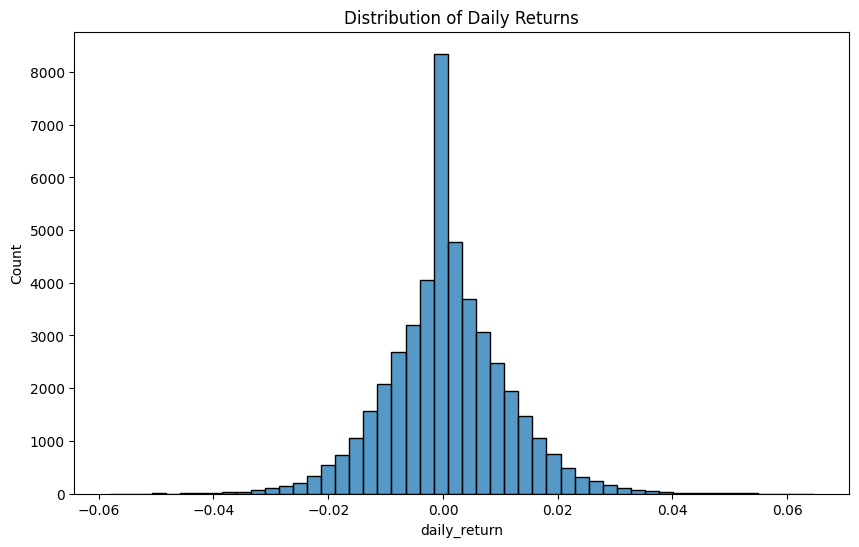

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.show()

In [6]:
cagr_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].sort_values("date")

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        (fund_data.iloc[-1]["date"] -
         fund_data.iloc[0]["date"]).days
    ) / 365

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
risk_free_rate = 0.065

sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    sharpe = (
        (returns.mean()*252 - risk_free_rate)
        /
        (returns.std())
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head()

,amfi_code,sharpe_ratio
34,148567,364.969375
30,120843,329.299480
36,148569,311.202366
19,119551,304.483175
25,120505,297.385502


In [8]:
cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [9]:
sharpe_df.head()

,amfi_code,sharpe_ratio
34,148567,364.969375
30,120843,329.299480
36,148569,311.202366
19,119551,304.483175
25,120505,297.385502


In [10]:
risk_free_rate = 0.065

sortino_results = []

for fund in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    sortino = (
        (returns.mean()*252 - risk_free_rate)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,601.182382
30,120843,595.808648
36,148569,541.022309
19,119551,539.347317
25,120505,511.396941


In [11]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [12]:
drawdown_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    running_max = fund_data["nav"].cummax()

    drawdown = (
        fund_data["nav"] /
        running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [13]:
cagr_df.to_csv(
    "../reports/cagr_results.csv",
    index=False
)

sharpe_df.to_csv(
    "../reports/sharpe_results.csv",
    index=False
)

sortino_df.to_csv(
    "../reports/sortino_results.csv",
    index=False
)

drawdown_df.to_csv(
    "../reports/drawdown_results.csv",
    index=False
)

print("Files Saved")

Files Saved


In [14]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [15]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

alpha_beta_results = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = regression.intercept * 252
        beta = regression.slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [16]:
scorecard = cagr_df.copy()

scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "alpha"]
    ],
    on="amfi_code"
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

scorecard["fund_score"] = (
      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["dd_rank"] * 0.10
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,cagr,return_rank,sharpe_ratio,sharpe_rank,alpha,alpha_rank,max_drawdown,dd_rank,fund_score
7,102886,0.011709,40.0,-51.869565,36.0,0.028969,40.0,-0.280011,35.0,32.50
17,119095,0.015205,39.0,-19.145340,33.0,0.048016,37.0,-0.516778,39.0,31.25
0,100016,0.026352,37.0,-50.782301,35.0,0.037476,39.0,-0.247344,34.0,31.05
22,119599,0.020531,38.0,-14.411030,32.0,0.048824,36.0,-0.525742,40.0,30.60
1,100025,0.044551,36.0,-142.907888,39.0,0.042818,38.0,-0.043083,4.0,28.55


In [17]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Deliverables Saved")

Deliverables Saved


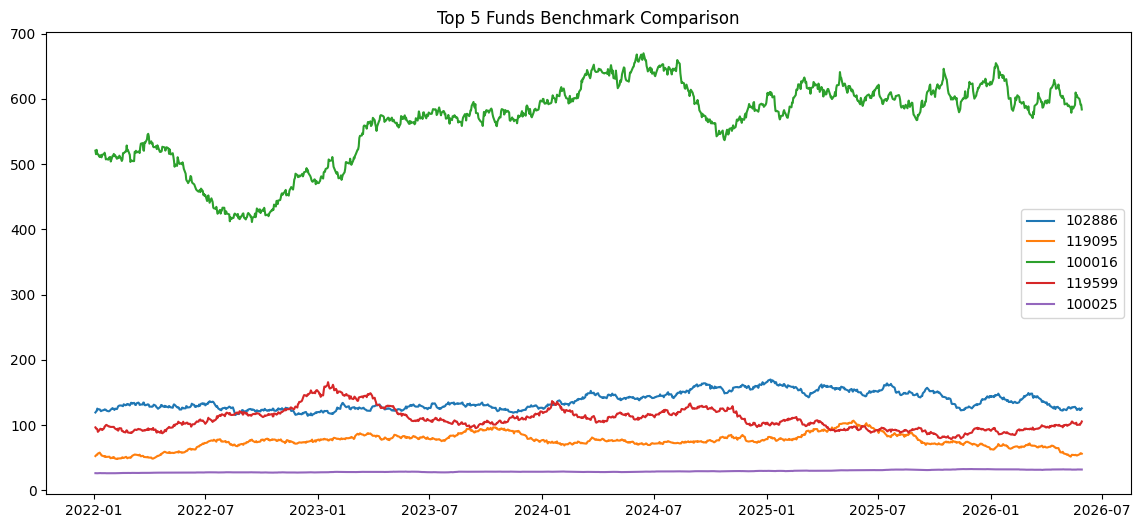

In [18]:
top5 = scorecard.head(5)["amfi_code"]

plt.figure(figsize=(14,6))

for fund in top5:

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds Benchmark Comparison"
)

plt.show()

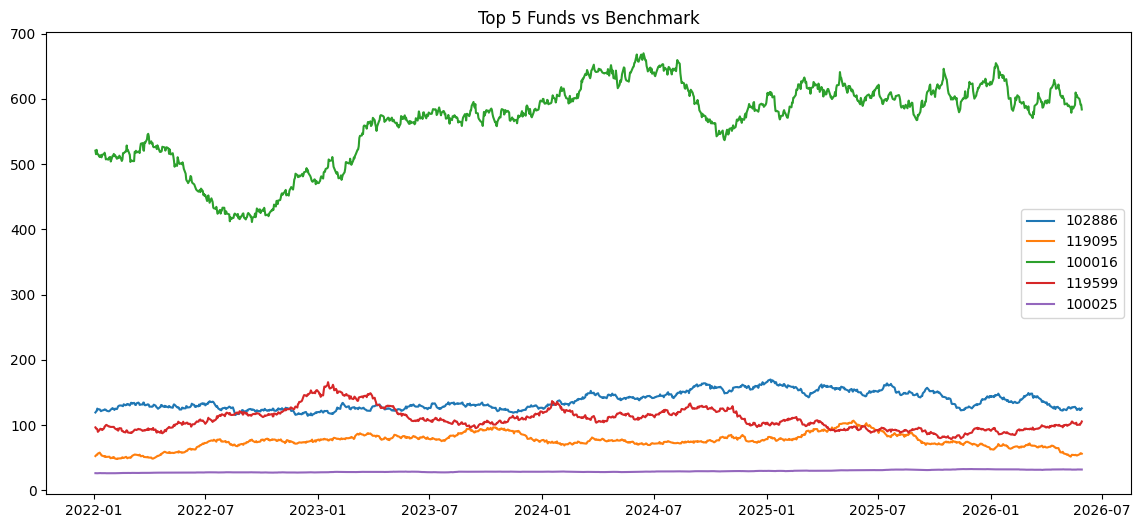

In [19]:
plt.figure(figsize=(14,6))

for fund in top5:

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "../reports/benchmark_comparison_chart.png"
)

plt.show()